In [52]:
import os
import numpy as np
import pandas as pd
import pyBigWig as pbw
import torch
from tangermeme.predict import predict
from tangermeme.product import apply_pairwise
from tangermeme.deep_lift_shap import deep_lift_shap, _nonlinear
from tangermeme.plot import plot_logo
from vinson.io import SamplesDensityExtractor
from vinson.utils import intervals_to_ohe
from vinson.interpretation import dinucleotide_shuffle, force_strict_ohe

from vinson.models.helpers import _Exp
from vinson.models.sequence import BassetTrunkEmbed, CellEmbedding, EmbedModel
from genome_tools import GenomicInterval
from genome_tools.data.extractors import FastaExtractor, TabixExtractor


# === Plotting ===
import matplotlib as mpl
import matplotlib.pyplot as plt
import subprocess
import matplotlib.patches as mpatches
import matplotlib.font_manager as fm
from matplotlib import rcParams
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
import seaborn as sns

# === Custom Fonts for Matplotlib ===
font_dir = os.path.expanduser("/home/mbrannon/.fonts")
font_files = fm.findSystemFonts(fontpaths=[font_dir])
for font_file in font_files:
    fm.fontManager.addfont(font_file)
plt.rcParams["font.family"] = "IBM Plex Sans"
rcParams["font.sans-serif"] = ["IBM Plex Sans"]


In [3]:
# Create model
embed = CellEmbedding(n_inputs=637, n_layers=0, n_outputs=256)
trunk = BassetTrunkEmbed(embed.n_outputs)
model = EmbedModel(trunk, embed, regression=True)

In [4]:
pretrained_state_dict = torch.load(
    "/home/jvierstra/proj/vinson/models/data_AUG3_with_warmup_and_decay_v2/checkpoints/epoch=3-step=1851994-val_loss=16.16.ckpt",
    map_location=torch.device("cpu"),
)["state_dict"]

model.load_state_dict(pretrained_state_dict)

/tmp/ipykernel_12733/292516220.py:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  pretrained_state_dict = torch.load(


<All keys matched successfully>

In [6]:
#select region
fasta_file = "/net/seq/data/genomes/human/GRCh38/noalts/GRCh38_no_alts.fa"  
fasta_extr = FastaExtractor(fasta_file)
interval = GenomicInterval("chr2", 60_495_037, 60_495_338)
mid = (interval.start + interval.end) // 2
interval = GenomicInterval(interval.chrom, mid, mid).widen(672)

embeddings_df = pd.read_csv("/home/jvierstra/proj/vinson/data/embeddings.tsv", sep="\t", index_col=0)

X_BCL11A = intervals_to_ohe(interval, seqlen=1344, fasta_extr=fasta_extr)

In [10]:
class Wrapper(torch.nn.Module):
    def __init__(self, model):
        super(Wrapper, self).__init__()
        self.model = model
        self.exp = _Exp()
    def forward(self, seq, embed):
        return self.exp(self.model(seq, embed))

model_wrapper = Wrapper(model)
model_wrapper = model_wrapper.eval()

In [11]:
#predict region
Y_BCL11A = apply_pairwise(
    predict, 
    model_wrapper, 
    torch.as_tensor(X_BCL11A, dtype=torch.float32), 
    args=(torch.as_tensor(embeddings_df.T.values, dtype=torch.float32),),
    device="cpu", 
    verbose=True
)

4159it [00:12, 343.92it/s]


In [8]:
#get embeddings 
from openTSNE import TSNE

tsne = TSNE(
    perplexity=20,
    metric="euclidean",
    n_jobs=1,
    random_state=42,
    verbose=True,
)

embedding_train = tsne.fit(embeddings_df.T.to_numpy())

--------------------------------------------------------------------------------
TSNE(early_exaggeration=12, perplexity=20, random_state=42, verbose=True)
--------------------------------------------------------------------------------
===> Finding 60 nearest neighbors using Annoy approximate search using euclidean distance...
   --> Time elapsed: 3.77 seconds
===> Calculating affinity matrix...
   --> Time elapsed: 0.19 seconds
===> Calculating PCA-based initialization...
   --> Time elapsed: 0.06 seconds
===> Running optimization with exaggeration=12.00, lr=346.58 for 250 iterations...
Iteration   50, KL divergence 3.4591, 50 iterations in 6.7613 sec
Iteration  100, KL divergence 3.3978, 50 iterations in 5.9542 sec
Iteration  150, KL divergence 3.3735, 50 iterations in 6.0277 sec
Iteration  200, KL divergence 3.3629, 50 iterations in 6.0642 sec
Iteration  250, KL divergence 3.3576, 50 iterations in 5.9816 sec
   --> Time elapsed: 30.79 seconds
===> Running optimization with exaggerat

In [26]:
#get obs densities
embeddings_file="/home/jvierstra/proj/vinson/data/embeddings.tsv"

pattern = "/net/seq/data2/projects/ENCODE4Plus/hotspot3/human/dnase/peak_calls.v23/{x}/{x}.normalized_density.bw"

density_extr = SamplesDensityExtractor(embeddings_file, pattern)

dens = density_extr[interval.center]

100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 4159/4159 [03:15<00:00, 21.32it/s]


Text(0.5, 0.98, 'Predicted DHS activity across cell types')

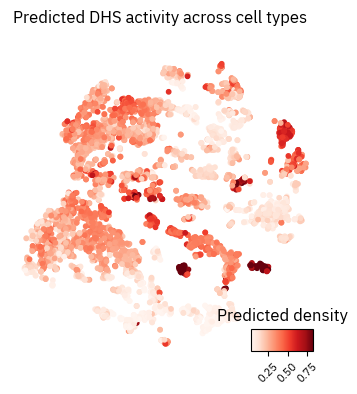

In [35]:
values = Y_BCL11A.squeeze().detach().cpu().numpy()

# set vmin/vmax by percentiles
vmin = np.percentile(values, 2)    # 2nd percentile
vmax = np.percentile(values, 98)   # 98th percentile

fig, ax = plt.subplots()
fig.set_size_inches(4, 4)

sc = ax.scatter(
    embedding_train[:, 0],
    embedding_train[:, 1],
    c=values,
    s=10,
    cmap="Reds",
    vmin=vmin,
    vmax=vmax
)


axins = inset_axes(ax, width="20%", height="7%", loc="lower right")

axins.set_title("Predicted density")
cbar = fig.colorbar(sc, cax=axins, orientation="horizontal")
for label in cbar.ax.get_xticklabels():
    label.set_rotation(45)
    label.set_fontsize(8)

ax.axis('off')


fig.suptitle("Predicted DHS activity across cell types")


Text(0.5, 0.98, 'Observed DHS activity across cell types')

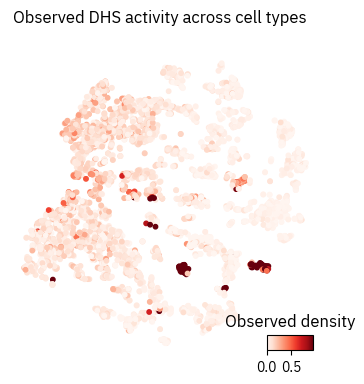

In [36]:
fig, ax = plt.subplots()
fig.set_size_inches(4, 4)

values = dens

# set vmin/vmax by percentiles
vmin = np.percentile(values, 2)    # 2nd percentile
vmax = np.percentile(values, 98)   # 98th percentile

sc = ax.scatter(
    embedding_train[:, 0],
    embedding_train[:, 1],
    s=10,
    c=values,
    cmap="Reds",
    vmin=vmin,
    vmax=vmax
)
axins = inset_axes(
    ax,
    width="15%",  # width: 50% of parent_bbox width
    height="5%",  # height: 5%
    loc="lower right",
)
fig.colorbar(sc, cax=axins, orientation="horizontal")
axins.set_title("Observed density")

ax.axis('off')


fig.suptitle("Observed DHS activity across cell types")


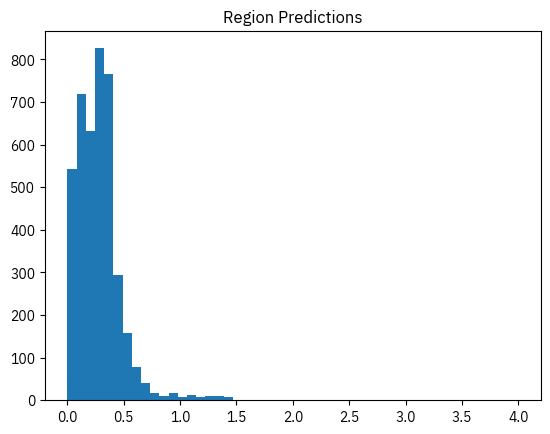

In [39]:
plt.hist(Y_BCL11A.squeeze(), bins=np.linspace(0, 4, 50))
plt.title("Region Predictions")
plt.show()

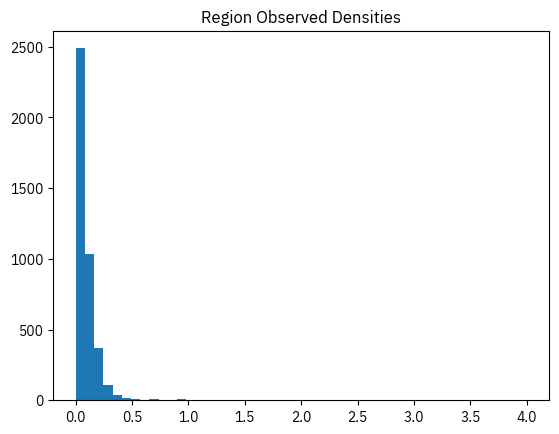

In [40]:
plt.hist(dens, bins=np.linspace(0, 4, 50))
plt.title("Region Observed Densities")
plt.show()

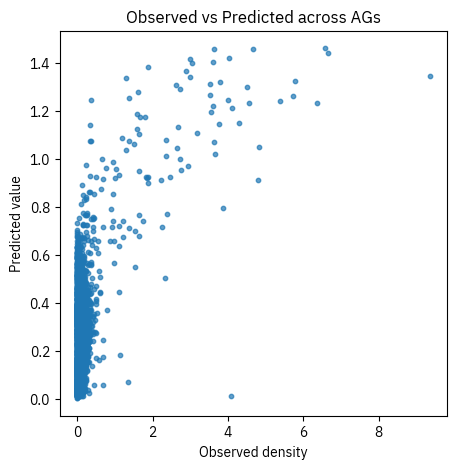

In [41]:
pred_1d = Y_BCL11A.squeeze().detach().cpu().numpy()

# make sure dens is aligned
dens_1d = dens.values

# scatter plot
fig, ax = plt.subplots(figsize=(5,5))
ax.scatter(dens_1d, pred_1d, s=10, alpha=0.7)

ax.set_xlabel("Observed density")
ax.set_ylabel("Predicted value")
ax.set_title("Observed vs Predicted across AGs")

plt.show()


In [43]:
from scipy.stats import pearsonr
r, p = pearsonr(dens_1d,pred_1d)
print(f"Pearson r = {r:.3f}, p = {p:.2e}")


Pearson r = 0.568, p = 0.00e+00


#### Shap

In [ ]:
#get erythroid consensus shap score

In [50]:
#keep x region
_X = torch.tensor(X_BCL11A, dtype=torch.float32)

In [44]:
#filter embedings for represenstative ags

#representative embeddings
rep_embed = pd.read_table('/net/seq/data2/projects/sabramov/SuperIndex/hotspot3/w_babachi_new.v23/ml_prediction/representative_samples_by_annotation_stratified.tsv')


In [93]:
np.unique(rep_embed["extended_annotation"].values)

array(['Adrenal', 'Astrocyte', 'B-cell', 'Basal ganglia', 'CMP',
       'Cerebellum', 'Cerebral cortex', 'Colon', 'Dendritic',
       'Endothelium', 'Epithelium', 'Erythroid', 'Eye',
       'Fetal life support', 'Fibroblast', 'Heart', 'Hepatic',
       'Intestine', 'Kidney', 'Limbic system', 'Lung', 'Macrophage',
       'Monocyte', 'Muscle', 'Myoblast', 'NK-cell', 'Ovary', 'Pancreas',
       'Pluripotent/Pluripotent-derived', 'Spinal cord', 'Stomach',
       'Stroma', 'T-cell', 'Thyroid'], dtype=object)

In [123]:
ags_want = rep_embed[rep_embed['extended_annotation']=='Monocyte'].sample_id.values

In [124]:
embeddings_df = pd.read_csv("/home/jvierstra/proj/vinson/data/embeddings.tsv", sep="\t", index_col=0)
filtered_embedding = embeddings_df[ags_want].values

# Convert to tensor with shape (1, embedding_dim)
rep_cell_embed = torch.tensor(filtered_embedding, dtype=torch.float32)


In [125]:
all_attrs = []
for i in range(rep_cell_embed.shape[1]):  # num samples
    embed_vec = rep_cell_embed[:, i].unsqueeze(0)  # (1, 627)
    attrs = deep_lift_shap(
        model_wrapper,
        _X,
        args=(embed_vec,),
        device="cpu",
        references=dinucleotide_shuffle,
        additional_nonlinear_ops={_Exp: _nonlinear}
    )
    all_attrs.append(attrs)

In [126]:
#get mean
attrs_stack = torch.stack(all_attrs, dim=0)
mean_attrs = attrs_stack.mean(dim=0)

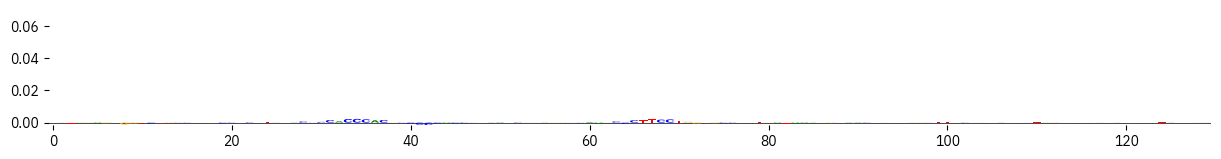

In [127]:
# Plot averaged SHAP scores
fig, ax = plt.subplots()
plot_logo(mean_attrs[0][:,670:800], ax=ax)  # Adjusted region
ax.set_ylim(top=0.07)
fig.set_size_inches(15, 1.5)
plt.show()